In [9]:
import pandas as pd
from prophet import Prophet
import joblib

# -----------------------------
# LOAD DATA
# -----------------------------
df = pd.read_csv("dummy_trip_updates.csv")

df["arrival_dt"] = pd.to_datetime(df["arrival_time"], unit="s")
df = df.sort_values(["route_id", "stop_id", "arrival_dt"])

df["headway_sec"] = df.groupby(["route_id", "stop_id"])["arrival_dt"].diff().dt.total_seconds()
df["headway_min"] = df["headway_sec"] / 60

# -----------------------------
# SELECT ONE ROUTE + STOP FOR MODEL
# -----------------------------
route = "25B"     # route_id is string
stop = 1001       # FIXED: stop_id must be integer, not string

ts = df[(df["route_id"] == route) & (df["stop_id"] == stop)][["arrival_dt", "headway_min"]]

# Drop NaN headways (first row only)
ts = ts.dropna()

# Prophet requires columns: ds, y
ts = ts.rename(columns={"arrival_dt": "ds", "headway_min": "y"})

print("Rows in training dataset:", ts.shape[0])
print(ts.head())

# -----------------------------
# TRAIN PROPHET MODEL
# -----------------------------
model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=False
)

model.fit(ts)

# -----------------------------
# FUTURE PREDICTIONS
# -----------------------------
future = model.make_future_dataframe(periods=30, freq="min")
forecast = model.predict(future)

# -----------------------------
# SAVE MODEL
# -----------------------------
joblib.dump(model, "headway_forecast_model.pkl")

print("Forecasting model saved successfully!")


Rows in training dataset: 999
                   ds         y
1 2024-01-01 06:10:07  5.700000
2 2024-01-01 06:15:49  5.700000
3 2024-01-01 06:20:41  4.866667
4 2024-01-01 06:26:18  5.616667
5 2024-01-01 06:31:33  5.250000


20:23:54 - cmdstanpy - INFO - Chain [1] start processing
20:23:55 - cmdstanpy - INFO - Chain [1] done processing


Forecasting model saved successfully!


In [11]:
import pandas as pd
from prophet import Prophet
import joblib
from pathlib import Path

# -----------------------------
# LOAD DATA
# -----------------------------
df = pd.read_csv("dummy_trip_updates.csv")
df["arrival_dt"] = pd.to_datetime(df["arrival_time"], unit="s")
df = df.sort_values(["route_id", "stop_id", "arrival_dt"])

df["headway_sec"] = df.groupby(["route_id", "stop_id"])["arrival_dt"].diff().dt.total_seconds()
df["headway_min"] = df["headway_sec"] / 60

# -----------------------------
# UNIQUE ROUTE/STOP PAIRS
# -----------------------------
pairs = df[["route_id", "stop_id"]].drop_duplicates()

models_dir = Path("headway_models")
models_dir.mkdir(exist_ok=True)

for _, row in pairs.iterrows():
    route = row["route_id"]
    stop = row["stop_id"]

    ts = df[(df["route_id"] == route) & (df["stop_id"] == stop)][["arrival_dt", "headway_min"]]
    ts = ts.dropna()
    if len(ts) < 20:
        continue  # skip tiny series

    ts = ts.rename(columns={"arrival_dt": "ds", "headway_min": "y"})

    model = Prophet(
        daily_seasonality=True,
        weekly_seasonality=True,
        yearly_seasonality=False
    )
    model.fit(ts)

    fname = models_dir / f"headway_{route}_{stop}.pkl"
    joblib.dump(model, fname)
    print(f"Saved model for route {route}, stop {stop} -> {fname}")

print("All eligible headway models trained.")


20:28:25 - cmdstanpy - INFO - Chain [1] start processing
20:28:25 - cmdstanpy - INFO - Chain [1] done processing


Saved model for route 25B, stop 1001 -> headway_models\headway_25B_1001.pkl


20:28:26 - cmdstanpy - INFO - Chain [1] start processing
20:28:26 - cmdstanpy - INFO - Chain [1] done processing


Saved model for route 25B, stop 1002 -> headway_models\headway_25B_1002.pkl


20:28:26 - cmdstanpy - INFO - Chain [1] start processing
20:28:26 - cmdstanpy - INFO - Chain [1] done processing
20:28:27 - cmdstanpy - INFO - Chain [1] start processing


...

Saved model for route 30, stop 4002 -> headway_models\headway_30_4002.pkl


20:28:33 - cmdstanpy - INFO - Chain [1] start processing
20:28:34 - cmdstanpy - INFO - Chain [1] done processing


Saved model for route 30, stop 4003 -> headway_models\headway_30_4003.pkl


20:28:34 - cmdstanpy - INFO - Chain [1] start processing
20:28:34 - cmdstanpy - INFO - Chain [1] done processing


Saved model for route 30, stop 4004 -> headway_models\headway_30_4004.pkl
All eligible headway models trained.


In [12]:
import pandas as pd
from prophet import Prophet
import joblib
from pathlib import Path

# -----------------------------
# LOAD DATA
# -----------------------------
df = pd.read_csv("dummy_trip_updates.csv")
df["arrival_dt"] = pd.to_datetime(df["arrival_time"], unit="s")
df = df.sort_values(["route_id", "stop_id", "arrival_dt"])

df["delay_min"] = df["delay"] / 60.0

pairs = df[["route_id", "stop_id"]].drop_duplicates()

models_dir = Path("delay_models")
models_dir.mkdir(exist_ok=True)

for _, row in pairs.iterrows():
    route = row["route_id"]
    stop = row["stop_id"]

    ts = df[(df["route_id"] == route) & (df["stop_id"] == stop)][["arrival_dt", "delay_min"]]
    ts = ts.dropna()
    if len(ts) < 20:
        continue

    ts = ts.rename(columns={"arrival_dt": "ds", "delay_min": "y"})

    model = Prophet(
        daily_seasonality=True,
        weekly_seasonality=True,
        yearly_seasonality=False
    )
    model.fit(ts)

    fname = models_dir / f"delay_{route}_{stop}.pkl"
    joblib.dump(model, fname)
    print(f"Saved delay model for route {route}, stop {stop} -> {fname}")

print("All eligible delay models trained.")


20:28:54 - cmdstanpy - INFO - Chain [1] start processing
20:28:55 - cmdstanpy - INFO - Chain [1] done processing


Saved delay model for route 25B, stop 1001 -> delay_models\delay_25B_1001.pkl


20:28:55 - cmdstanpy - INFO - Chain [1] start processing
20:28:55 - cmdstanpy - INFO - Chain [1] done processing


Saved delay model for route 25B, stop 1002 -> delay_models\delay_25B_1002.pkl


20:28:56 - cmdstanpy - INFO - Chain [1] start processing
20:28:56 - cmdstanpy - INFO - Chain [1] done processing


...

Saved delay model for route 30, stop 4002 -> delay_models\delay_30_4002.pkl


20:29:03 - cmdstanpy - INFO - Chain [1] start processing
20:29:03 - cmdstanpy - INFO - Chain [1] done processing


Saved delay model for route 30, stop 4003 -> delay_models\delay_30_4003.pkl


20:29:03 - cmdstanpy - INFO - Chain [1] start processing
20:29:03 - cmdstanpy - INFO - Chain [1] done processing


Saved delay model for route 30, stop 4004 -> delay_models\delay_30_4004.pkl
All eligible delay models trained.


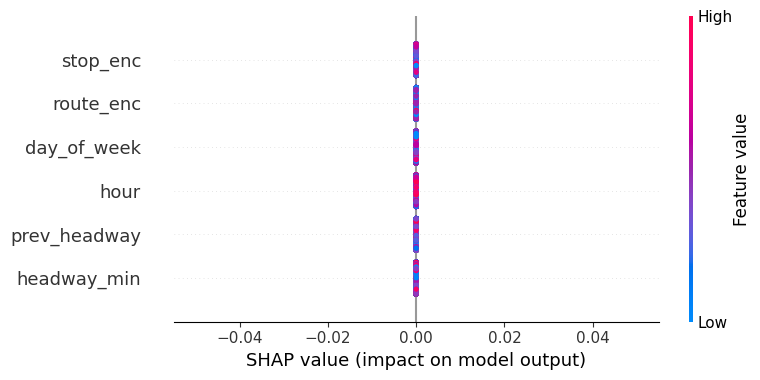

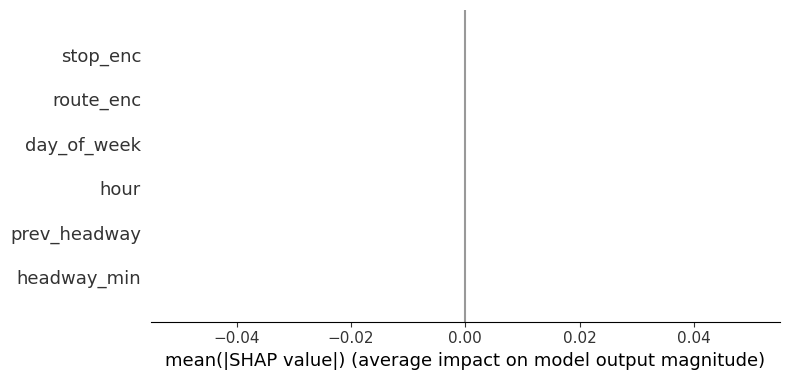

SHAP analysis complete.


In [21]:
import pandas as pd
import joblib
import shap

# -----------------------------
# LOAD DATA + MODEL
# -----------------------------
df = pd.read_csv("dummy_trip_updates.csv")

df["arrival_dt"] = pd.to_datetime(df["arrival_time"], unit="s")
df = df.sort_values(["route_id", "stop_id", "arrival_dt"])

# Headway + delay
df["headway_sec"] = df.groupby(["route_id", "stop_id"])["arrival_dt"].diff().dt.total_seconds()
df["headway_min"] = df["headway_sec"] / 60
df["delay_min"] = df["delay"] / 60.0

# Missing features (required)
df["prev_headway"] = df.groupby(["route_id", "stop_id"])["headway_min"].shift(1).fillna(10)
df["prev_delay"] = df.groupby(["route_id", "stop_id"])["delay_min"].shift(1).fillna(0)

# Time features
df["hour"] = df["arrival_dt"].dt.hour
df["day_of_week"] = df["arrival_dt"].dt.dayofweek

# Load model + encoders
le_route = joblib.load("bunch_route_encoder.pkl")
le_stop = joblib.load("bunch_stop_encoder.pkl")
model = joblib.load("bunching_prediction_model.pkl")

df["route_enc"] = le_route.transform(df["route_id"])
df["stop_enc"] = le_stop.transform(df["stop_id"])

# Feature list
features = [
    "headway_min",
    "prev_headway",
    "hour",
    "day_of_week",
    "route_enc",
    "stop_enc"
]

X = df[features].fillna(0)

# -----------------------------
# SHAP EXPLAINER
# -----------------------------
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

# -----------------------------
# FIX: Handle 1-output or 2-output SHAP
# -----------------------------
if isinstance(shap_values, list):
    # Binary classifier → shap_values[1] is the positive class
    sv = shap_values[1]
else:
    # New SHAP versions → returns a single matrix
    sv = shap_values

# -----------------------------
# PLOTS
# -----------------------------
shap.summary_plot(sv, X)
shap.summary_plot(sv, X, plot_type="bar")

print("SHAP analysis complete.")


In [22]:
import pandas as pd
import joblib
from pathlib import Path

HEADWAY_MODELS_DIR = Path("headway_models")
DELAY_MODELS_DIR = Path("delay_models")

def load_headway_model(route_id: str, stop_id: int):
    path = HEADWAY_MODELS_DIR / f"headway_{route_id}_{stop_id}.pkl"
    return joblib.load(path)

def load_delay_model(route_id: str, stop_id: int):
    path = DELAY_MODELS_DIR / f"delay_{route_id}_{stop_id}.pkl"
    return joblib.load(path)

def build_realtime_series(df_recent: pd.DataFrame):
    df_recent = df_recent.copy()
    df_recent["arrival_dt"] = pd.to_datetime(df_recent["arrival_time"], unit="s")
    df_recent = df_recent.sort_values("arrival_dt")
    df_recent["headway_sec"] = df_recent["arrival_dt"].diff().dt.total_seconds()
    df_recent["headway_min"] = df_recent["headway_sec"] / 60
    return df_recent

def forecast_next_headways(route_id: str, stop_id: int, df_recent: pd.DataFrame, minutes_ahead: int = 30):
    model = load_headway_model(route_id, stop_id)
    df_recent = build_realtime_series(df_recent)
    last_time = df_recent["arrival_dt"].max()

    future = model.make_future_dataframe(periods=minutes_ahead, freq="min")
    future = future[future["ds"] > last_time]

    forecast = model.predict(future)
    return forecast[["ds", "yhat"]]

def forecast_next_delays(route_id: str, stop_id: int, df_recent: pd.DataFrame, minutes_ahead: int = 30):
    model = load_delay_model(route_id, stop_id)
    df_recent = df_recent.copy()
    df_recent["arrival_dt"] = pd.to_datetime(df_recent["arrival_time"], unit="s")
    last_time = df_recent["arrival_dt"].max()

    future = model.make_future_dataframe(periods=minutes_ahead, freq="min")
    future = future[future["ds"] > last_time]

    forecast = model.predict(future)
    return forecast[["ds", "yhat"]]


In [23]:
import pandas as pd

df = pd.read_csv("dummy_trip_updates.csv")
df_recent = df[(df["route_id"] == "25B") & (df["stop_id"] == 1001)].tail(10)

print(df_recent)


    route_id  stop_id  arrival_time  delay   timestamp
990      25B     1001    1704387070   -105  1704387070
991      25B     1001    1704387368    252  1704387368
992      25B     1001    1704387657    271  1704387657
993      25B     1001    1704387948     53  1704387948
994      25B     1001    1704388223    138  1704388223
995      25B     1001    1704388551    283  1704388551
996      25B     1001    1704388901    131  1704388901
997      25B     1001    1704389187    178  1704389187
998      25B     1001    1704389433      4  1704389433
999      25B     1001    1704389752     56  1704389752


In [25]:
from realtime_forecasting_utils import forecast_next_headways

forecast = forecast_next_headways("25B", 1001, df_recent, minutes_ahead=30)
print(forecast)


                    ds      yhat
0  2024-01-04 17:36:52  4.898504
1  2024-01-04 17:37:52  4.899014
2  2024-01-04 17:38:52  4.899537
3  2024-01-04 17:39:52  4.900071
4  2024-01-04 17:40:52  4.900616
5  2024-01-04 17:41:52  4.901174
6  2024-01-04 17:42:52  4.901744
7  2024-01-04 17:43:52  4.902325
8  2024-01-04 17:44:52  4.902918
9  2024-01-04 17:45:52  4.903524
10 2024-01-04 17:46:52  4.904141
11 2024-01-04 17:47:52  4.904770
12 2024-01-04 17:48:52  4.905411
13 2024-01-04 17:49:52  4.906064
14 2024-01-04 17:50:52  4.906729
15 2024-01-04 17:51:52  4.907406
16 2024-01-04 17:52:52  4.908095
17 2024-01-04 17:53:52  4.908795
18 2024-01-04 17:54:52  4.909508
19 2024-01-04 17:55:52  4.910233
20 2024-01-04 17:56:52  4.910970
21 2024-01-04 17:57:52  4.911718
22 2024-01-04 17:58:52  4.912479
23 2024-01-04 17:59:52  4.913252
24 2024-01-04 18:00:52  4.914036
25 2024-01-04 18:01:52  4.914833
26 2024-01-04 18:02:52  4.915641
27 2024-01-04 18:03:52  4.916461
28 2024-01-04 18:04:52  4.917293
29 2024-01

In [26]:
import pandas as pd

df = pd.read_csv("dummy_trip_updates.csv")
df_recent = df[(df["route_id"] == "25B") & (df["stop_id"] == 1001)].tail(10)

forecast = forecast_next_headways("25B", 1001, df_recent, 30)
print(forecast)


                    ds      yhat
0  2024-01-04 17:36:52  4.898504
1  2024-01-04 17:37:52  4.899014
2  2024-01-04 17:38:52  4.899537
3  2024-01-04 17:39:52  4.900071
4  2024-01-04 17:40:52  4.900616
5  2024-01-04 17:41:52  4.901174
6  2024-01-04 17:42:52  4.901744
7  2024-01-04 17:43:52  4.902325
8  2024-01-04 17:44:52  4.902918
9  2024-01-04 17:45:52  4.903524
10 2024-01-04 17:46:52  4.904141
11 2024-01-04 17:47:52  4.904770
12 2024-01-04 17:48:52  4.905411
13 2024-01-04 17:49:52  4.906064
14 2024-01-04 17:50:52  4.906729
15 2024-01-04 17:51:52  4.907406
16 2024-01-04 17:52:52  4.908095
17 2024-01-04 17:53:52  4.908795
18 2024-01-04 17:54:52  4.909508
19 2024-01-04 17:55:52  4.910233
20 2024-01-04 17:56:52  4.910970
21 2024-01-04 17:57:52  4.911718
22 2024-01-04 17:58:52  4.912479
23 2024-01-04 17:59:52  4.913252
24 2024-01-04 18:00:52  4.914036
25 2024-01-04 18:01:52  4.914833
26 2024-01-04 18:02:52  4.915641
27 2024-01-04 18:03:52  4.916461
28 2024-01-04 18:04:52  4.917293
29 2024-01